## Imports

In [1]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import gaussian_kde

from analysis_helpers.constants import FIG_DIR

## Functions

In [2]:
def draw_cloud(ax, center, sigma, color, max_alpha=None):
    """Render a sampling distribution as a Gaussian fading out from `center`."""
    if max_alpha is None:
        max_alpha = CLOUD_MAX_ALPHA
    
    grid = np.linspace(-CLOUD_EXTENT, CLOUD_EXTENT, CLOUD_GRID_N)
    xx, yy = np.meshgrid(grid, grid)
    sq_dists = (xx - center[0]) ** 2 + (yy - center[1]) ** 2

    rgba = np.zeros((CLOUD_GRID_N, CLOUD_GRID_N, 4))
    rgba[..., :3] = mcolors.to_rgb(color)
    rgba[..., 3] = max_alpha * np.exp(-sq_dists / (2 * sigma ** 2))
    ax.imshow(rgba,
              extent=(-CLOUD_EXTENT, CLOUD_EXTENT, -CLOUD_EXTENT, CLOUD_EXTENT),
              origin='lower',
              interpolation='bilinear',
              zorder=0)
    return ax

In [3]:
def draw_sketch(ax, hyp):
    """Draw the sampling cartoon for one hypothesis (panel A or panel C)."""
    delayed_center = episode if hyp == 'h1' else selected_imm

    draw_cloud(ax, delayed_center, DELAYED_SIGMAS[hyp], DELAYED_COLOR)
    draw_cloud(ax, episode, IMMEDIATE_SIGMA, IMMEDIATE_COLOR)
    draw_cloud(ax, 
               episode, 
               EPISODE_SIGMA, 
               EPISODE_COLOR, 
               max_alpha=EPISODE_CLOUD_ALPHA)

    # candidate recountings
    ax.scatter(*delayed[hyp].T, 
               s=DOT_SIZE, 
               color=DELAYED_COLOR,
               alpha=DOT_ALPHA, 
               linewidths=0, 
               zorder=2)
    ax.scatter(*immediate.T, 
               s=DOT_SIZE, 
               color=IMMEDIATE_COLOR,
               alpha=DOT_ALPHA, 
               linewidths=0, 
               zorder=3)

    # actual recountings & episode
    ax.scatter(*delayed[hyp][selected_del_ix], 
               s=SELECTED_DOT_SIZE,
               color=DELAYED_COLOR, 
               edgecolors=SELECTED_EDGECOLOR,
               linewidths=SELECTED_LINEWIDTH, 
               zorder=4)
    ax.scatter(*selected_imm, 
               s=SELECTED_DOT_SIZE, 
               color=IMMEDIATE_COLOR,
               edgecolors=SELECTED_EDGECOLOR, 
               linewidths=SELECTED_LINEWIDTH,
               zorder=5)
    ax.scatter(*episode, s=EPISODE_DOT_SIZE, color=EPISODE_COLOR, zorder=6)

    axes_lim = AXES_LIMS[hyp]
    ax.set_xlim(-axes_lim, axes_lim)
    ax.set_ylim(-axes_lim, axes_lim)
    ax.set_aspect('equal')
    ax.axis('off')

    # scale bar
    bar_width = SCALE_BAR_LENGTH / (2 * axes_lim)
    ax.plot([SCALE_BAR_X, SCALE_BAR_X + bar_width],
            [SCALE_BAR_Y, SCALE_BAR_Y],
            transform=ax.transAxes,
            color=SCALE_BAR_COLOR,
            lw=SCALE_BAR_LINEWIDTH,
            solid_capstyle='butt',
            clip_on=False)
    ax.text(SCALE_BAR_X + bar_width / 2,
            SCALE_BAR_Y + 0.015,
            f'{SCALE_BAR_LENGTH:g}',
            transform=ax.transAxes,
            color=SCALE_BAR_COLOR,
            fontsize=SCALE_BAR_FONTSIZE,
            ha='center',
            va='bottom')
    return ax

In [4]:
def draw_kdes(ax, hyp):
    """Draw the three distance distributions implied by one hypothesis."""
    grid = np.linspace(0, KDE_XMAX, KDE_GRID_N)
    for key, color, label in (
            ('imm_ep', IMMEDIATE_COLOR, 'Immediate vs. episode'),
            ('del_ep', DELAYED_COLOR, 'Delayed vs. episode'),
            ('del_imm', BETWEEN_COLOR, 'Delayed vs. immediate')
    ):
        density = gaussian_kde(dists[hyp][key], bw_method=KDE_BW_METHOD)(grid)
        ax.fill_between(grid, density, color=color, alpha=KDE_FILL_ALPHA, lw=0)
        ax.plot(grid, density, color=color, lw=KDE_LINEWIDTH, label=label)

    ax.set_xlim(0, KDE_XMAX)
    ax.set_ylabel('Density', fontsize=AXIS_LABEL_FONTSIZE)
    ax.tick_params(left=False, 
                   bottom=False, 
                   labelsize=TICKLABEL_FONTSIZE, 
                   pad=-1)
    sns.despine(ax=ax)
    return ax

In [5]:
def add_callout(text, xy_h1, xy_h2, text_xy):
    """Label a point in both sketch panels from one shared text block."""
    for ax, xy in ((a_ax, xy_h1), (c_ax, xy_h2)):
        ax.annotate('',
                    xy=xy,
                    xycoords=ax.transData,
                    xytext=text_xy,
                    textcoords=fig.transFigure,
                    arrowprops={'arrowstyle': '-',
                                'color': CALLOUT_COLOR,
                                'lw': CALLOUT_LINEWIDTH,
                                'shrinkA': 0,
                                'shrinkB': 4})
    fig.text(*text_xy, text,
             fontsize=CALLOUT_FONTSIZE,
             color=CALLOUT_COLOR,
             ha='center',
             va='center',
             ma='center',
             linespacing=1.4,
             bbox={'facecolor': 'white', 'edgecolor': 'none', 'pad': 3})

## Simulate recountings under each hypothesis

In [6]:
# parameters
RANDOM_SEED = 0
N_SAMPLES = 150
EPISODE_SIGMA = 0.55
IMMEDIATE_SIGMA = 1.00
SELECTED_IMM_RADIUS = 1.60
SELECTED_DEL_RADIUS = 1.60
DELAYED_SIGMAS = {'h1': 1.60, 'h2': 0.70}

# simulate
rng = np.random.default_rng(RANDOM_SEED)

episode = np.zeros(2)

# candidate immediate recountings (noisy versions of the episode)
immediate = rng.normal(size=(N_SAMPLES, 2)) * IMMEDIATE_SIGMA

# actual immediate recounting
imm_radii = np.linalg.norm(immediate, axis=1)
imm_angles = np.arctan2(immediate[:, 1], immediate[:, 0])
candidates = np.flatnonzero((imm_angles > np.deg2rad(20))
                            & (imm_angles < np.deg2rad(55)))
selected_imm_ix = candidates[
    np.argmin(np.abs(imm_radii[candidates] - SELECTED_IMM_RADIUS))
]
selected_imm = immediate[selected_imm_ix]

# candidate delayed recountings
delayed_draws = rng.normal(size=(N_SAMPLES, 2))
delayed = {
    'h1': episode + delayed_draws * DELAYED_SIGMAS['h1'],
    'h2': selected_imm + delayed_draws * DELAYED_SIGMAS['h2']
}

del_radii = np.linalg.norm(delayed_draws, axis=1)
del_angles = np.arctan2(delayed_draws[:, 1], delayed_draws[:, 0])
candidates = np.flatnonzero((del_angles > np.deg2rad(-70))
                            & (del_angles < np.deg2rad(-25)))
selected_del_ix = candidates[
    np.argmin(np.abs(del_radii[candidates] - SELECTED_DEL_RADIUS))
]

dists = {
    hyp: {
        'imm_ep': np.linalg.norm(immediate - episode, axis=1),
        'del_ep': np.linalg.norm(delayed[hyp] - episode, axis=1),
        'del_imm': np.linalg.norm(delayed[hyp] - selected_imm, axis=1)
    }
    for hyp in ('h1', 'h2')
}

for hyp, hyp_dists in dists.items():
    print(f'{hyp}: ' + ', '.join(f'mean {k} distance: {v.mean():.3f}'
                                 for k, v in hyp_dists.items()))

h1: mean imm_ep distance: 1.287, mean del_ep distance: 1.941, mean del_imm distance: 2.405
h2: mean imm_ep distance: 1.287, mean del_ep distance: 1.759, mean del_imm distance: 0.849


## Construct figure

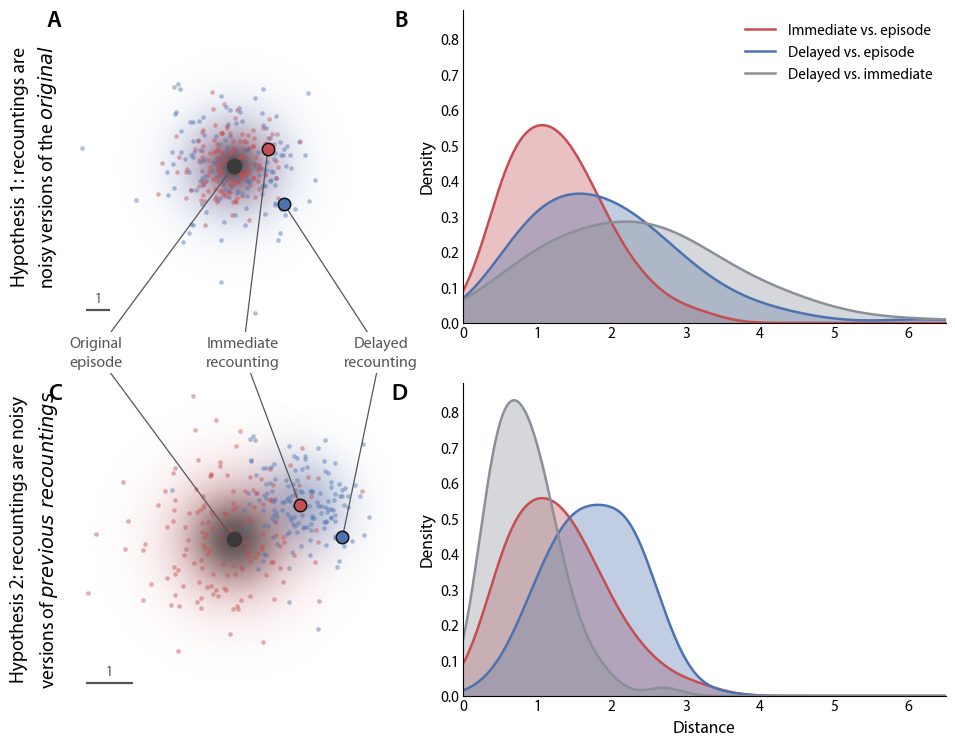

In [7]:
################################ CONFIG ################################

EPISODE_COLOR = '#3a3a3a'
IMMEDIATE_COLOR = '#c44e52'
DELAYED_COLOR = '#4c72b0'
BETWEEN_COLOR = '#8a8f98'

CLOUD_MAX_ALPHA = 0.46
EPISODE_CLOUD_ALPHA = 0.78
CLOUD_GRID_N = 400
CLOUD_EXTENT = 9.0

AXES_LIMS = {'h1': 6.45, 'h2': 3.35}

SCALE_BAR_LENGTH = 1.0
SCALE_BAR_X = 0.03
SCALE_BAR_Y = 0.04
SCALE_BAR_COLOR = '#555'
SCALE_BAR_LINEWIDTH = 1.6
SCALE_BAR_FONTSIZE = 10

DOT_SIZE = 11
DOT_ALPHA = 0.45
SELECTED_DOT_SIZE = 80
SELECTED_EDGECOLOR = '#111'
SELECTED_LINEWIDTH = 1.1
EPISODE_DOT_SIZE = 105

KDE_FILL_ALPHA = 0.35
KDE_LINEWIDTH = 1.8
KDE_GRID_N = 512
KDE_XMAX = 6.5
KDE_YPAD = 1.06

PANEL_LABEL_FONTSIZE = 17
ROW_LABEL_FONTSIZE = 14
CALLOUT_FONTSIZE = 11.5
LEGEND_FONTSIZE = 11
AXIS_LABEL_FONTSIZE = 12.5
TICKLABEL_FONTSIZE = 11

CALLOUT_COLOR = '#555'
CALLOUT_LINEWIDTH = 0.9
KDE_BW_METHOD = 0.5

CALLOUT_BAND_Y = 0.5
CALLOUTS = (('Original\nepisode', 0.06),
            ('Immediate\nrecounting', 0.53),
            ('Delayed\nrecounting', 0.97))

ROW_LABELS = (
    'Hypothesis 1: recountings are\nnoisy versions of the $\\it{original}$',
    'Hypothesis 2: recountings are noisy\n'
    'versions of $\\it{previous\\ recountings}$'
)
ROW_LABEL_X = 0.074

FIGSIZE = (10, 7.8)



################################ LAYOUT ################################

fig = plt.figure(figsize=FIGSIZE)
gs = fig.add_gridspec(3, 2,
                      width_ratios=[0.79, 1.21],
                      height_ratios=[1, 0.19, 1],
                      wspace=0.18,
                      hspace=0.0,
                      left=0.115,
                      right=0.985,
                      top=0.965,
                      bottom=0.085)
a_ax = fig.add_subplot(gs[0, 0])
b_ax = fig.add_subplot(gs[0, 1])
c_ax = fig.add_subplot(gs[2, 0])
d_ax = fig.add_subplot(gs[2, 1], sharex=b_ax, sharey=b_ax)


################################ PANELS ################################

draw_sketch(a_ax, 'h1')
draw_sketch(c_ax, 'h2')
draw_kdes(b_ax, 'h1')
draw_kdes(d_ax, 'h2')

d_ax.set_xlabel('Distance', fontsize=AXIS_LABEL_FONTSIZE)

b_ax.set_ylim(0, KDE_YPAD * max(line.get_ydata().max()
                                for ax in (b_ax, d_ax)
                                for line in ax.lines))

b_ax.legend(fontsize=LEGEND_FONTSIZE, frameon=False, loc='upper right')


############################### CALLOUTS ###############################

fig.canvas.draw()

a_pos, c_pos = a_ax.get_position(), c_ax.get_position()
label_y = c_pos.y1 + CALLOUT_BAND_Y * (a_pos.y0 - c_pos.y1)

callout_points = (
    (episode, episode),
    (selected_imm, selected_imm),
    (delayed['h1'][selected_del_ix], delayed['h2'][selected_del_ix])
)
for (label, x_frac), (xy_h1, xy_h2) in zip(CALLOUTS, callout_points):
    add_callout(label, xy_h1, xy_h2,
                (a_pos.x0 + x_frac * a_pos.width, label_y))

    
############################## ROW LABELS ##############################

for row_label, ax in zip(ROW_LABELS, (a_ax, c_ax)):
    pos = ax.get_position()
    fig.text(ROW_LABEL_X,
             (pos.y0 + pos.y1) / 2,
             row_label,
             fontsize=ROW_LABEL_FONTSIZE,
             rotation=90,
             ha='center',
             va='center',
             ma='center',
             linespacing=1.5)

    
############################# PANEL LABELS #############################

for label, ax, dx in (('A', a_ax, 0.015), ('B', b_ax, 0.055),
                      ('C', c_ax, 0.015), ('D', d_ax, 0.055)):
    fig.text(ax.get_position().x0 - dx,
             ax.get_position().y1 - 0.028,
             label,
             fontsize=PANEL_LABEL_FONTSIZE,
             fontweight='semibold',
             ha='right',
             va='bottom')

# plt.savefig(FIG_DIR / 'hypotheses.pdf', bbox_inches='tight')

plt.show()